410184


Solving topologies using MHSA algorithm...

Topology: star
Total Communication Cost (MHSA): 652.46

Topology: line
Total Communication Cost (MHSA): 503.62

Topology: cross
Total Communication Cost (MHSA): 503.92

Topology: ring
Total Communication Cost (MHSA): 492.0

Topology: quad
Total Communication Cost (MHSA): 531.16

Topology: star-traingl
Total Communication Cost (MHSA): 622.4

Topology: line-triangl
Total Communication Cost (MHSA): 532.2

Topology: cross-triangl
Total Communication Cost (MHSA): 552.08


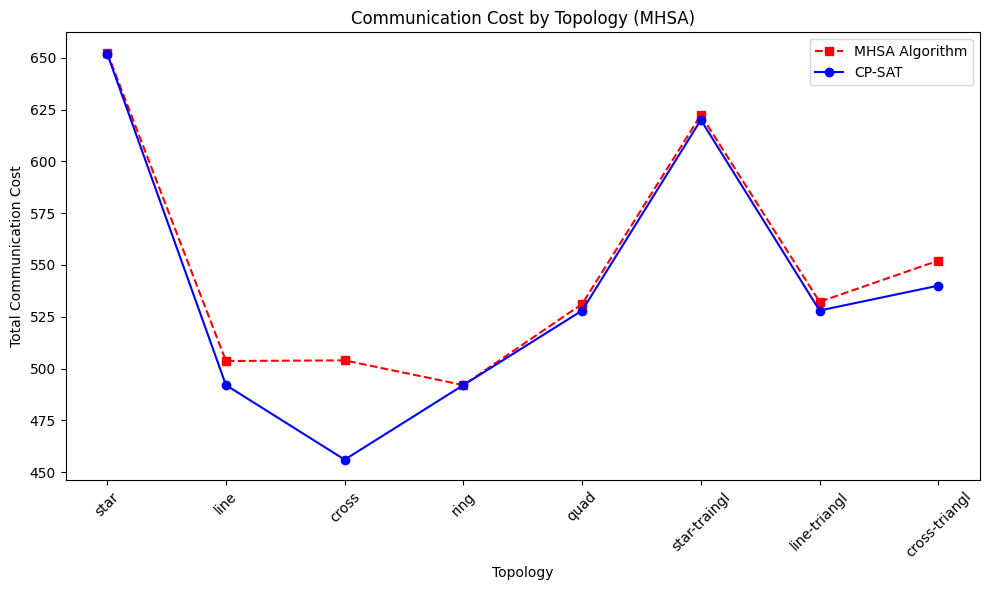

In [ ]:
"""
MHSA Topology Qubit Allocation Solver with Cost Plot

This program runs the MHSA algorithm for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install networkx matplotlib
"""

import random
import math
import matplotlib.pyplot as plt
import networkx as nx

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 14   # Fixed for all topologies.

# Global cost mapping
costs_from_distance = [0, 12, 22, 32, 42]

# Global coupled pairs (common for all topologies)
coupled_pairs = [
    ((0, 1), 7),
    ((2, 3), 7),
    ((4, 5), 7),
    ((6, 7), 7),
    ((8, 9), 7),
    ((3, 4), 6),
    ((5, 6), 6),
    ((7, 8), 6),
    ((9, 10), 6),
    ((2, 4), 6),
    ((4, 6), 6),
    ((6, 8), 6),
    ((8, 10), 6),
    ((1, 2), 4),
    ((0, 2), 4),
    ((10, 11), 4),
    ((11, 12), 2),
    ((10, 12), 2),
    ((11, 13), 2),
    ((10, 13), 2),
    ((12, 13), 1)
]

# Define topology configurations
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}

def calculate_overhead(mapping, dist_matrix):
    overhead = 0
    for (q1, q2), count in coupled_pairs:
        v1 = mapping[q1]
        v2 = mapping[q2]
        d = dist_matrix[v1][v2]
        overhead += count * costs_from_distance[d]
    return overhead

def random_initial_mapping(capacities):
    allocation = {}
    available = {v: capacities[v] for v in range(NUM_NODES)}
    qubits = list(range(NUM_QUBITS))
    random.shuffle(qubits)
    for q in qubits:
        valid_nodes = [n for n in available if available[n] > 0]
        node = random.choice(valid_nodes)
        allocation[q] = node
        available[node] -= 1
    return allocation

def local_search(mapping, capacities, dist_matrix):
    current = mapping.copy()
    best_cost = calculate_overhead(current, dist_matrix)
    improved = True

    while improved:
        improved = False
        for q in range(NUM_QUBITS):
            for node in range(NUM_NODES):
                if current[q] == node:
                    continue
                count_in_node = sum(1 for v in current.values() if v == node)
                if count_in_node >= capacities[node]:
                    continue
                candidate = current.copy()
                candidate[q] = node
                candidate_cost = calculate_overhead(candidate, dist_matrix)
                if candidate_cost < best_cost:
                    current = candidate
                    best_cost = candidate_cost
                    improved = True
    return current, best_cost

def run_mhsa_for_topology(topo_config, alpha=0.9, nstage=50, neqlb=5, nstuck=5):
    capacities = topo_config["capacities"]
    dist_matrix = topo_config["distance_matrix"]

    best_mapping = None
    best_cost = float("inf")
    current_mapping = random_initial_mapping(capacities)
    current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)

    for stage in range(nstage):
        temp = 300
        stuck = 0
        while stuck < nstuck:
            for _ in range(neqlb):
                q = random.randint(0, NUM_QUBITS - 1)
                valid_nodes = [n for n in range(NUM_NODES) if sum(1 for v in current_mapping.values() if v == n) < capacities[n] or current_mapping[q] == n]
                if not valid_nodes:
                    continue
                node = random.choice(valid_nodes)
                neighbor = current_mapping.copy()
                neighbor[q] = node

                delta = calculate_overhead(neighbor, dist_matrix) - calculate_overhead(current_mapping, dist_matrix)
                if delta < 0 or random.random() < math.exp(-delta / temp):
                    current_mapping = neighbor
                    current_cost = calculate_overhead(current_mapping, dist_matrix)
                    if current_cost < best_cost:
                        best_mapping = current_mapping.copy()
                        best_cost = current_cost
                    stuck = 0
                else:
                    stuck += 1
            temp *= alpha
        current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)
        if current_cost < best_cost:
            best_mapping = current_mapping.copy()
            best_cost = current_cost
    return best_mapping, best_cost

def main():
    topology_names = []
    mhsa_costs = []
    costs=[652,492,456,492,528,620,528,540]
    print("\n=================================================")
    print("Solving topologies using MHSA algorithm...")

    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        cost=0
        for i in range(100):
          solution, cost_val = run_mhsa_for_topology(topo)
          cost+=cost_val
        # solution2, cost_val2 = solve_topology(topo)
        cost/=100
        print(f"Total Communication Cost (MHSA): {cost}")
        # print(f"Total Communication Cost (CP-SAT): {cost_val2}")
        topology_names.append(name)
        mhsa_costs.append(cost)
        # costs.append(cost_val2)


    # Plot result
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, mhsa_costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.plot(x, costs, marker='o', linestyle='-', color='b',label='CP-SAT')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()





if __name__ == '__main__':
    main()


clip


Solving topologies using MHSA algorithm...

Topology: star
Total Communication Cost (MHSA): 180809.7

Topology: line
Total Communication Cost (MHSA): 181886.16

Topology: cross
Total Communication Cost (MHSA): 159388.24

Topology: ring
Total Communication Cost (MHSA): 158059.76

Topology: quad
Total Communication Cost (MHSA): 172768.68

Topology: star-traingl
Total Communication Cost (MHSA): 175241.32

Topology: line-triangl
Total Communication Cost (MHSA): 182642.98

Topology: cross-triangl
Total Communication Cost (MHSA): 179958.68


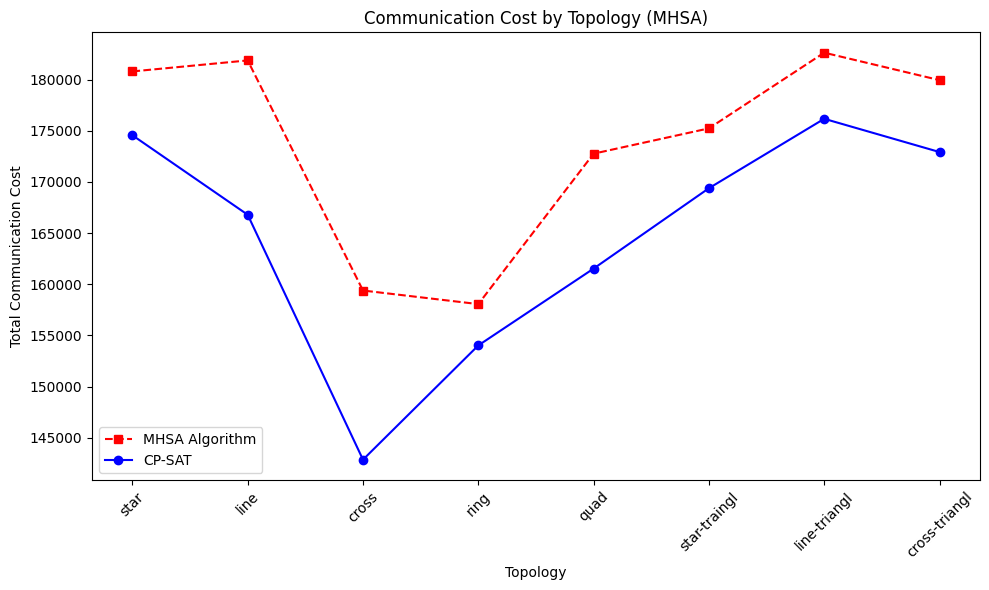

In [ ]:


import random
import math
import matplotlib.pyplot as plt
import networkx as nx

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 14   # Fixed for all topologies.

# Global cost mapping
costs_from_distance = [0, 12, 22, 32, 42]

# Global coupled pairs (common for all topologies)
coupled_pairs = [
 ((12, 13), 794),
((8, 11), 744),
((8, 9), 736),
((7, 11), 700),
((11, 12), 625),
((5, 12), 570),
((6, 11), 488),
((9, 10), 456),
((9, 11), 424),
((6, 12), 414),
((7, 10), 367),
((5, 13), 300),
((7, 12), 299),
((4, 8), 292),
((6, 9), 279),
((8, 10), 260),
((10, 11), 256),
((0, 13), 240),
((4, 9), 228),
((4, 11), 220),
((7, 9), 215),
((2, 11), 208),
((5, 10), 207),
((6, 8), 200),
((4, 5), 196),
((3, 11), 194),
((5, 8), 192),
((3, 4), 184),
((10, 13), 178),
((0, 10), 176),
((8, 13), 176),
((7, 8), 174),
((4, 13), 172),
((0, 9), 168),
((6, 10), 168),
((8, 12), 168),
((3, 10), 152),
((4, 10), 144),
((2, 3), 144),
((5, 9), 140),
((4, 7), 136),
((6, 7), 114),
((2, 13), 112),
((3, 8), 108),
((9, 13), 106),
((5, 11), 104),
((2, 12), 96),
((1, 9), 88),
((3, 9), 84),
((1, 11), 84),
((5, 6), 80),
((1, 12), 80),
((0, 4), 80),
((5, 7), 72),
((4, 6), 72),
((1, 5), 68),
((4, 12), 60),
((1, 3), 56),
((1, 10), 56),
((3, 13), 56),
((1, 13), 53),
((2, 8), 52),
((2, 5), 50),
((0, 3), 48),
((2, 9), 48),
((1, 2), 48),
((6, 13), 46),
((2, 10), 44),
((1, 6), 40),
((3, 12), 40),
((3, 6), 40),
((0, 5), 32),
((0, 2), 32),
((2, 4), 32),
((2, 6), 30),
((3, 5), 28),
((0, 6), 24),
((0, 12), 24),
((7, 13), 22),
((11, 13), 20),
((1, 7), 16),
((2, 7), 16),
((0, 7), 8),
((1, 8), 8),
((3, 7), 6),
((9, 12), 4),
((0, 8), 1)
]

# Define topology configurations
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}

def calculate_overhead(mapping, dist_matrix):
    overhead = 0
    for (q1, q2), count in coupled_pairs:
        v1 = mapping[q1]
        v2 = mapping[q2]
        d = dist_matrix[v1][v2]
        overhead += count * costs_from_distance[d]
    return overhead

def random_initial_mapping(capacities):
    allocation = {}
    available = {v: capacities[v] for v in range(NUM_NODES)}
    qubits = list(range(NUM_QUBITS))
    random.shuffle(qubits)
    for q in qubits:
        valid_nodes = [n for n in available if available[n] > 0]
        node = random.choice(valid_nodes)
        allocation[q] = node
        available[node] -= 1
    return allocation

def local_search(mapping, capacities, dist_matrix):
    current = mapping.copy()
    best_cost = calculate_overhead(current, dist_matrix)
    improved = True

    while improved:
        improved = False
        for q in range(NUM_QUBITS):
            for node in range(NUM_NODES):
                if current[q] == node:
                    continue
                count_in_node = sum(1 for v in current.values() if v == node)
                if count_in_node >= capacities[node]:
                    continue
                candidate = current.copy()
                candidate[q] = node
                candidate_cost = calculate_overhead(candidate, dist_matrix)
                if candidate_cost < best_cost:
                    current = candidate
                    best_cost = candidate_cost
                    improved = True
    return current, best_cost

def run_mhsa_for_topology(topo_config, alpha=0.9, nstage=50, neqlb=5, nstuck=5):
    capacities = topo_config["capacities"]
    dist_matrix = topo_config["distance_matrix"]

    best_mapping = None
    best_cost = float("inf")
    current_mapping = random_initial_mapping(capacities)
    current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)

    for stage in range(nstage):
        temp = 20000
        stuck = 0
        while stuck < nstuck:
            for _ in range(neqlb):
                q = random.randint(0, NUM_QUBITS - 1)
                valid_nodes = [n for n in range(NUM_NODES) if sum(1 for v in current_mapping.values() if v == n) < capacities[n] or current_mapping[q] == n]
                if not valid_nodes:
                    continue
                node = random.choice(valid_nodes)
                neighbor = current_mapping.copy()
                neighbor[q] = node

                delta = calculate_overhead(neighbor, dist_matrix) - calculate_overhead(current_mapping, dist_matrix)
                if delta < 0 or random.random() < math.exp(-delta / temp):
                    current_mapping = neighbor
                    current_cost = calculate_overhead(current_mapping, dist_matrix)
                    if current_cost < best_cost:
                        best_mapping = current_mapping.copy()
                        best_cost = current_cost
                    stuck = 0
                else:
                    stuck += 1
            temp *= alpha
        current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)
        if current_cost < best_cost:
            best_mapping = current_mapping.copy()
            best_cost = current_cost
    return best_mapping, best_cost

def main():
    topology_names = []
    mhsa_costs = []
    costs=[174570,166796,142850,154018,161532,169390,176178,172928]
    print("\n=================================================")
    print("Solving topologies using MHSA algorithm...")

    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        cost=0
        for i in range(100):
          solution, cost_val = run_mhsa_for_topology(topo)
          cost+=cost_val
        # solution2, cost_val2 = solve_topology(topo)
        cost/=100
        print(f"Total Communication Cost (MHSA): {cost}")
        # print(f"Total Communication Cost (CP-SAT): {cost_val2}")
        topology_names.append(name)
        mhsa_costs.append(cost)
        # costs.append(cost_val2)


    # Plot result
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, mhsa_costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.plot(x, costs, marker='o', linestyle='-', color='b',label='CP-SAT')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()





if __name__ == '__main__':
    main()


cm42a


Solving topologies using MHSA algorithm...

Topology: star
Total Communication Cost (MHSA): 6445.14

Topology: line
Total Communication Cost (MHSA): 5337.14

Topology: cross
Total Communication Cost (MHSA): 4520.16

Topology: ring
Total Communication Cost (MHSA): 5532.66

Topology: quad
Total Communication Cost (MHSA): 5670.66

Topology: star-traingl
Total Communication Cost (MHSA): 6041.98

Topology: line-triangl
Total Communication Cost (MHSA): 5513.38

Topology: cross-triangl
Total Communication Cost (MHSA): 5867.92


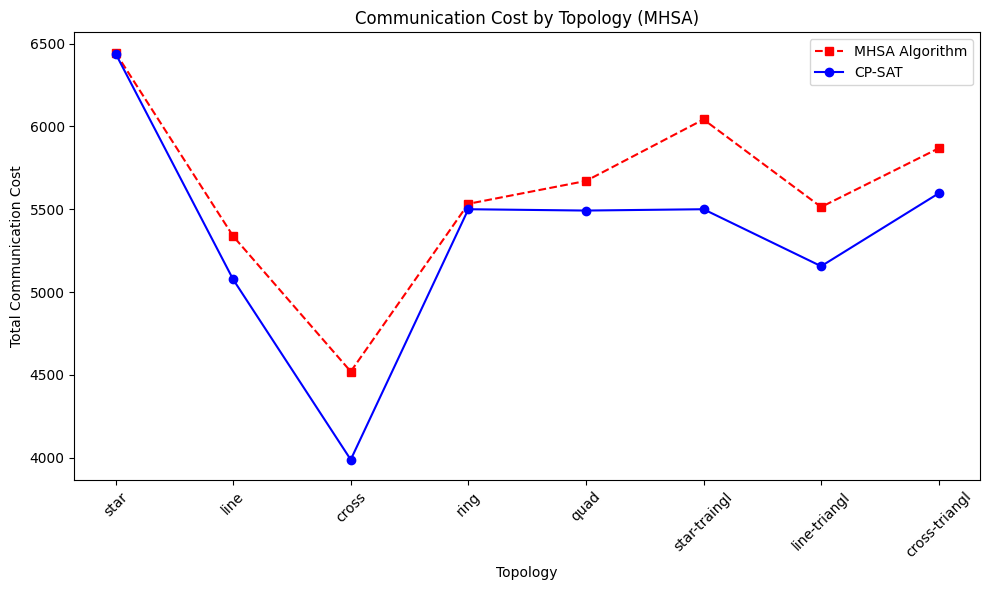

In [ ]:
"""
MHSA Topology Qubit Allocation Solver with Cost Plot

This program runs the MHSA algorithm for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install networkx matplotlib
"""

import random
import math
import matplotlib.pyplot as plt
import networkx as nx

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 14   # Fixed for all topologies.

# Global cost mapping
costs_from_distance = [0, 12, 22, 32, 42]

# Global coupled pairs (common for all topologies)
coupled_pairs = [
((8, 11), 104),
((12, 13), 92),
((8, 9), 72),
((9, 11), 72),
((9, 10), 58),
((11, 12), 38),
((8, 13), 36),
((8, 12), 32),
((10, 13), 30),
((7, 11), 28),
((11, 13), 28),
((10, 11), 18),
((6, 10), 14),
((8, 10), 14),
((7, 9), 12),
((2, 10), 11),
((7, 10), 8),
((4, 10), 8),
((7, 8), 8),
((7, 12), 8),
((7, 13), 8),
((0, 10), 8),
((6, 11), 6),
((6, 9), 4),
((3, 9), 4),
((3, 10), 4),
((2, 9), 4),
((5, 9), 4),
((5, 10), 4),
((4, 9), 4),
((4, 13), 4),
((2, 13), 4),
((6, 13), 4),
((0, 9), 4),
((1, 9), 4),
((1, 10), 4),
((0, 13), 4),
((2, 11), 2)
]

# Define topology configurations
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}

def calculate_overhead(mapping, dist_matrix):
    overhead = 0
    for (q1, q2), count in coupled_pairs:
        v1 = mapping[q1]
        v2 = mapping[q2]
        d = dist_matrix[v1][v2]
        overhead += count * costs_from_distance[d]
    return overhead

def random_initial_mapping(capacities):
    allocation = {}
    available = {v: capacities[v] for v in range(NUM_NODES)}
    qubits = list(range(NUM_QUBITS))
    random.shuffle(qubits)
    for q in qubits:
        valid_nodes = [n for n in available if available[n] > 0]
        node = random.choice(valid_nodes)
        allocation[q] = node
        available[node] -= 1
    return allocation

def local_search(mapping, capacities, dist_matrix):
    current = mapping.copy()
    best_cost = calculate_overhead(current, dist_matrix)
    improved = True

    while improved:
        improved = False
        for q in range(NUM_QUBITS):
            for node in range(NUM_NODES):
                if current[q] == node:
                    continue
                count_in_node = sum(1 for v in current.values() if v == node)
                if count_in_node >= capacities[node]:
                    continue
                candidate = current.copy()
                candidate[q] = node
                candidate_cost = calculate_overhead(candidate, dist_matrix)
                if candidate_cost < best_cost:
                    current = candidate
                    best_cost = candidate_cost
                    improved = True
    return current, best_cost

def run_mhsa_for_topology(topo_config, alpha=0.9, nstage=50, neqlb=5, nstuck=5):
    capacities = topo_config["capacities"]
    dist_matrix = topo_config["distance_matrix"]

    best_mapping = None
    best_cost = float("inf")
    current_mapping = random_initial_mapping(capacities)
    current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)

    for stage in range(nstage):
        temp = 1100
        stuck = 0
        while stuck < nstuck:
            for _ in range(neqlb):
                q = random.randint(0, NUM_QUBITS - 1)
                valid_nodes = [n for n in range(NUM_NODES) if sum(1 for v in current_mapping.values() if v == n) < capacities[n] or current_mapping[q] == n]
                if not valid_nodes:
                    continue
                node = random.choice(valid_nodes)
                neighbor = current_mapping.copy()
                neighbor[q] = node

                delta = calculate_overhead(neighbor, dist_matrix) - calculate_overhead(current_mapping, dist_matrix)
                if delta < 0 or random.random() < math.exp(-delta / temp):
                    current_mapping = neighbor
                    current_cost = calculate_overhead(current_mapping, dist_matrix)
                    if current_cost < best_cost:
                        best_mapping = current_mapping.copy()
                        best_cost = current_cost
                    stuck = 0
                else:
                    stuck += 1
            temp *= alpha
        current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)
        if current_cost < best_cost:
            best_mapping = current_mapping.copy()
            best_cost = current_cost
    return best_mapping, best_cost

def main():
    topology_names = []
    mhsa_costs = []
    costs=[6440,5076,3988,5500,5492,5500,5156,5596]
    print("\n=================================================")
    print("Solving topologies using MHSA algorithm...")

    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        cost=0
        for i in range(100):
          solution, cost_val = run_mhsa_for_topology(topo)
          cost+=cost_val
        # solution2, cost_val2 = solve_topology(topo)
        cost/=100
        print(f"Total Communication Cost (MHSA): {cost}")
        # print(f"Total Communication Cost (CP-SAT): {cost_val2}")
        topology_names.append(name)
        mhsa_costs.append(cost)
        # costs.append(cost_val2)


    # Plot result
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, mhsa_costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.plot(x, costs, marker='o', linestyle='-', color='b',label='CP-SAT')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()





if __name__ == '__main__':
    main()


sao2


Solving topologies using MHSA algorithm...

Topology: star
Total Communication Cost (MHSA): 159585.1

Topology: line
Total Communication Cost (MHSA): 141071.32

Topology: cross
Total Communication Cost (MHSA): 136018.02

Topology: ring
Total Communication Cost (MHSA): 137638.26

Topology: quad
Total Communication Cost (MHSA): 147002.54

Topology: star-traingl
Total Communication Cost (MHSA): 157731.64

Topology: line-triangl
Total Communication Cost (MHSA): 155738.3

Topology: cross-triangl
Total Communication Cost (MHSA): 152922.1


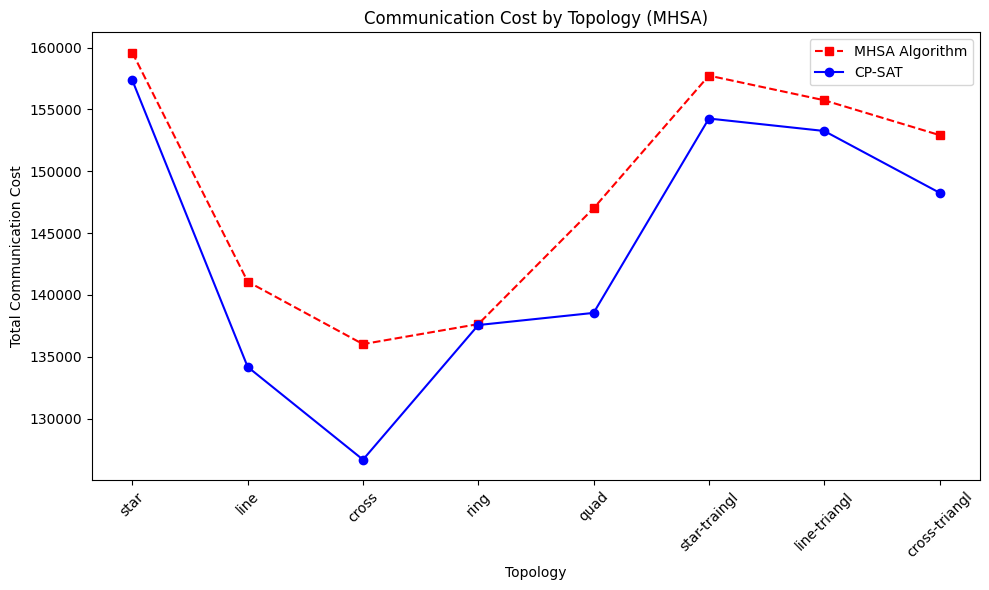

In [ ]:
"""
MHSA Topology Qubit Allocation Solver with Cost Plot

This program runs the MHSA algorithm for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install networkx matplotlib
"""

import random
import math
import matplotlib.pyplot as plt
import networkx as nx
import re
from collections import Counter

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 14   # Fixed for all topologies.

# Global cost mapping
costs_from_distance = [0, 12, 22, 32, 42]


# Define topology configurations
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}

def extract_cnot_operations(qasm_file):
    """Extracts CNOT pairs and counts from a given QASM file."""
    with open(qasm_file, 'r') as file:
        qasm_content = file.read()

    cnot_pattern = r'cx q\[(\d+)\],q\[(\d+)\]'
    cnot_pairs = re.findall(cnot_pattern, qasm_content)

    # Normalize pairs
    normalized_pairs = [tuple(sorted((int(a), int(b)))) for a, b in cnot_pairs]

    # Count occurrences
    return (Counter(normalized_pairs))

def calculate_overhead(mapping, dist_matrix):
    overhead = 0
    # print(coupled_pairs)
    for (q1, q2), count in coupled_pairs.items():
        v1 = mapping[q1]
        v2 = mapping[q2]
        d = dist_matrix[v1][v2]
        overhead += count * costs_from_distance[d]
    return overhead

def random_initial_mapping(capacities):
    allocation = {}
    available = {v: capacities[v] for v in range(NUM_NODES)}
    qubits = list(range(NUM_QUBITS))
    random.shuffle(qubits)
    for q in qubits:
        valid_nodes = [n for n in available if available[n] > 0]
        node = random.choice(valid_nodes)
        allocation[q] = node
        available[node] -= 1
    return allocation

def local_search(mapping, capacities, dist_matrix):
    current = mapping.copy()
    best_cost = calculate_overhead(current, dist_matrix)
    improved = True

    while improved:
        improved = False
        for q in range(NUM_QUBITS):
            for node in range(NUM_NODES):
                if current[q] == node:
                    continue
                count_in_node = sum(1 for v in current.values() if v == node)
                if count_in_node >= capacities[node]:
                    continue
                candidate = current.copy()
                candidate[q] = node
                candidate_cost = calculate_overhead(candidate, dist_matrix)
                if candidate_cost < best_cost:
                    current = candidate
                    best_cost = candidate_cost
                    improved = True
    return current, best_cost

def run_mhsa_for_topology(topo_config, alpha=0.9, nstage=50, neqlb=5, nstuck=5):
    capacities = topo_config["capacities"]
    dist_matrix = topo_config["distance_matrix"]

    best_mapping = None
    best_cost = float("inf")
    current_mapping = random_initial_mapping(capacities)
    current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)

    for stage in range(nstage):
        temp = 20000
        stuck = 0
        while stuck < nstuck:
            for _ in range(neqlb):
                q = random.randint(0, NUM_QUBITS - 1)
                valid_nodes = [n for n in range(NUM_NODES) if sum(1 for v in current_mapping.values() if v == n) < capacities[n] or current_mapping[q] == n]
                if not valid_nodes:
                    continue
                node = random.choice(valid_nodes)
                neighbor = current_mapping.copy()
                neighbor[q] = node

                delta = calculate_overhead(neighbor, dist_matrix) - calculate_overhead(current_mapping, dist_matrix)
                if delta < 0 or random.random() < math.exp(-delta / temp):
                    current_mapping = neighbor
                    current_cost = calculate_overhead(current_mapping, dist_matrix)
                    if current_cost < best_cost:
                        best_mapping = current_mapping.copy()
                        best_cost = current_cost
                    stuck = 0
                else:
                    stuck += 1
            temp *= alpha
        current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)
        if current_cost < best_cost:
            best_mapping = current_mapping.copy()
            best_cost = current_cost
    return best_mapping, best_cost

def main(qasm_file):
    topology_names = []
    mhsa_costs = []
    costs=[157344,134174,126676,137562,138544,154260,153254,148260]

    global coupled_pairs
    coupled_pairs = extract_cnot_operations(qasm_file)
    # print(coupled_pairs.items())
    print("\n=================================================")
    print("Solving topologies using MHSA algorithm...")

    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        cost=0
        for i in range(100):
          solution, cost_val = run_mhsa_for_topology(topo)
          cost+=cost_val
        # solution2, cost_val2 = solve_topology(topo)
        cost/=100
        print(f"Total Communication Cost (MHSA): {cost}")
        # print(f"Total Communication Cost (CP-SAT): {cost_val2}")
        topology_names.append(name)
        mhsa_costs.append(cost)
        # costs.append(cost_val2)


    # Plot result
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, mhsa_costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.plot(x, costs, marker='o', linestyle='-', color='b',label='CP-SAT')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()





if __name__ == '__main__':
    qasm_file ="/content/sao2_257.qasm"
    main(qasm_file)



ham15


Solving topologies using MHSA algorithm...

Topology: star
Total Communication Cost (MHSA): 42582.0

Topology: line
Total Communication Cost (MHSA): 40744.0

Topology: cross
Total Communication Cost (MHSA): 32310.0

Topology: ring
Total Communication Cost (MHSA): 47622.0

Topology: quad
Total Communication Cost (MHSA): 67722.0

Topology: star-traingl
Total Communication Cost (MHSA): 64260.0

Topology: line-triangl
Total Communication Cost (MHSA): 57954.0

Topology: cross-triangl
Total Communication Cost (MHSA): 61148.0


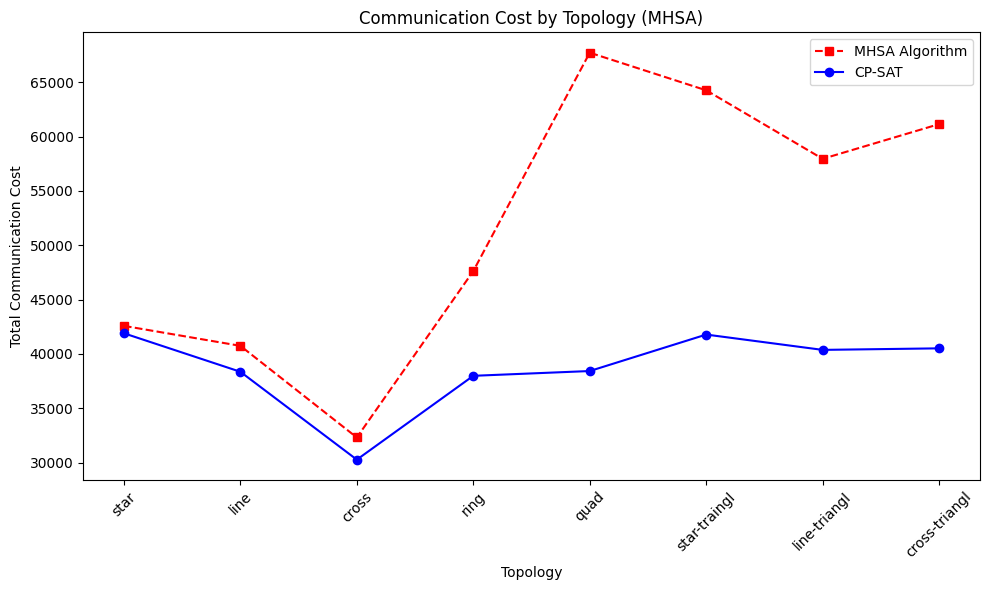

In [ ]:
"""
MHSA Topology Qubit Allocation Solver with Cost Plot

This program runs the MHSA algorithm for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install networkx matplotlib
"""

import random
import math
import matplotlib.pyplot as plt
import networkx as nx

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 15  # Fixed for all topologies.

# Global cost mapping
costs_from_distance = [0, 12, 22, 32, 42]

# Global coupled pairs (common for all topologies)
coupled_pairs = [
((10, 13), 305),
((12, 13), 292),
((11, 13), 181),
((9, 13), 180),
((11, 12), 178),
((10, 11), 176),
((13, 14), 174),
((10, 12), 170),
((12, 14), 148),
((9, 12), 131),
((9, 10), 130),
((9, 11), 129),
((1, 14), 112),
((11, 14), 112),
((10, 14), 97),
((8, 13), 80),
((8, 12), 70),
((8, 10), 68),
((8, 11), 68),
((7, 12), 60),
((2, 9), 54),
((5, 11), 54),
((7, 8), 48),
((7, 11), 46),
((5, 9), 42),
((8, 9), 40),
((5, 10), 40),
((2, 14), 36),
((1, 13), 36),
((1, 11), 32),
((2, 12), 32),
((1, 12), 32),
((2, 13), 30),
((7, 10), 29),
((2, 5), 25),
((6, 7), 24),
((2, 10), 24),
((3, 14), 24),
((9, 14), 22),
((5, 12), 22),
((5, 14), 21),
((6, 11), 20),
((6, 10), 18),
((3, 10), 16),
((2, 8), 16),
((2, 11), 16),
((7, 13), 12),
((6, 12), 12),
((4, 11), 12),
((4, 10), 12),
((7, 14), 12),
((3, 13), 12),
((8, 14), 10),
((6, 9), 9),
((5, 8), 9),
((4, 6), 8),
((3, 4), 8),
((1, 10), 8),
((5, 6), 8),
((7, 9), 8),
((3, 12), 8),
((5, 13), 8),
((1, 8), 4),
((3, 9), 4),
((3, 5), 4),
((0, 10), 4),
((0, 14), 4),
((4, 14), 4),
((6, 14), 4),
((4, 8), 2),
((3, 7), 2),
((2, 6), 2),
((1, 5), 2),
((0, 4), 2),
((4, 7), 1),
((3, 6), 1),
((1, 4), 1),
((0, 3), 1)



]

# Define topology configurations
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}

def calculate_overhead(mapping, dist_matrix):
    overhead = 0
    for (q1, q2), count in coupled_pairs:
        v1 = mapping[q1]
        v2 = mapping[q2]
        d = dist_matrix[v1][v2]
        overhead += count * costs_from_distance[d]
    return overhead

def random_initial_mapping(capacities):
    allocation = {}
    available = {v: capacities[v] for v in range(NUM_NODES)}
    qubits = list(range(NUM_QUBITS))
    random.shuffle(qubits)
    for q in qubits:
        valid_nodes = [n for n in available if available[n] > 0]
        node = random.choice(valid_nodes)
        allocation[q] = node
        available[node] -= 1
    return allocation

def local_search(mapping, capacities, dist_matrix):
    current = mapping.copy()
    best_cost = calculate_overhead(current, dist_matrix)
    improved = True

    while improved:
        improved = False
        for q in range(NUM_QUBITS):
            for node in range(NUM_NODES):
                if current[q] == node:
                    continue
                count_in_node = sum(1 for v in current.values() if v == node)
                if count_in_node >= capacities[node]:
                    continue
                candidate = current.copy()
                candidate[q] = node
                candidate_cost = calculate_overhead(candidate, dist_matrix)
                if candidate_cost < best_cost:
                    current = candidate
                    best_cost = candidate_cost
                    improved = True
    return current, best_cost

import time
import random
import math

def run_mhsa_for_topology(topo_config, alpha=0.9, nstage=50, neqlb=5, nstuck=5, time_limit=60):
    capacities = topo_config["capacities"]
    dist_matrix = topo_config["distance_matrix"]

    start_time = time.time()
    best_mapping = None
    best_cost = float("inf")
    current_mapping = random_initial_mapping(capacities)
    current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)

    for stage in range(nstage):
        temp = 4000
        stuck = 0
        while stuck < nstuck:
            if time.time() - start_time >= time_limit:
                return best_mapping, best_cost  # Terminate if time limit is reached

            for _ in range(neqlb):
                if time.time() - start_time >= time_limit:
                    return best_mapping, best_cost  # Terminate if time limit is reached

                q = random.randint(0, NUM_QUBITS - 1)
                valid_nodes = [
                    n
                    for n in range(NUM_NODES)
                    if sum(1 for v in current_mapping.values() if v == n) < capacities[n] or current_mapping[q] == n
                ]
                if not valid_nodes:
                    continue
                node = random.choice(valid_nodes)
                neighbor = current_mapping.copy()
                neighbor[q] = node

                delta = calculate_overhead(neighbor, dist_matrix) - calculate_overhead(current_mapping, dist_matrix)
                if delta < 0 or random.random() < math.exp(-delta / temp):
                    current_mapping = neighbor
                    current_cost = calculate_overhead(current_mapping, dist_matrix)
                    if current_cost < best_cost:
                        best_mapping = current_mapping.copy()
                        best_cost = current_cost
                    stuck = 0
                else:
                    stuck += 1
            temp *= alpha

        current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)
        if current_cost < best_cost:
            best_mapping = current_mapping.copy()
            best_cost = current_cost

    return best_mapping, best_cost


def main():
    topology_names = []
    mhsa_costs = []

    costs=[41900,38358,30270,37986,38426,41782,40372,40514]
    print("\n=================================================")
    print("Solving topologies using MHSA algorithm...")

    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        cost=0
        for i in range(1):
          solution, cost_val = run_mhsa_for_topology(topo)
          cost+=cost_val
        # solution2, cost_val2 = solve_topology(topo)
        cost/=1
        print(f"Total Communication Cost (MHSA): {cost}")
        # print(f"Total Communication Cost (CP-SAT): {cost_val2}")
        topology_names.append(name)
        mhsa_costs.append(cost)
        # costs.append(cost_val2)


    # Plot result
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, mhsa_costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.plot(x, costs, marker='o', linestyle='-', color='b',label='CP-SAT')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()





if __name__ == '__main__':
    main()


dc2


Solving topologies using MHSA algorithm...

Topology: star
Total Communication Cost (MHSA): 51355.4

Topology: line
Total Communication Cost (MHSA): 50901.8

Topology: cross
Total Communication Cost (MHSA): 46081.0

Topology: ring
Total Communication Cost (MHSA): 60581.6

Topology: quad
Total Communication Cost (MHSA): 67760.2

Topology: star-traingl
Total Communication Cost (MHSA): 65245.6

Topology: line-triangl
Total Communication Cost (MHSA): 71833.0

Topology: cross-triangl
Total Communication Cost (MHSA): 69004.6


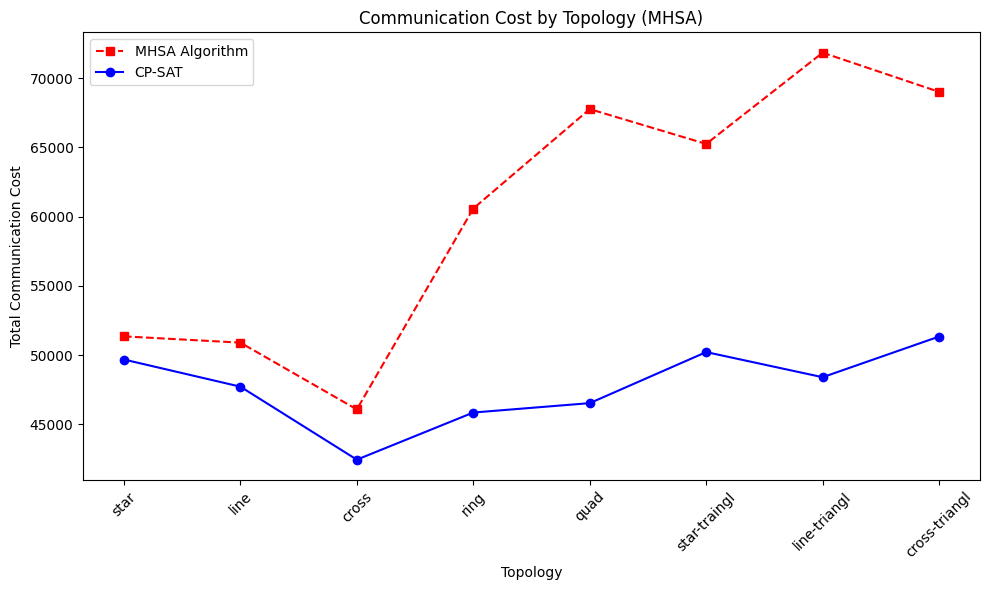

In [ ]:
"""
MHSA Topology Qubit Allocation Solver with Cost Plot

This program runs the MHSA algorithm for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install networkx matplotlib
"""

import random
import math
import matplotlib.pyplot as plt
import networkx as nx
import re
from collections import Counter

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 15  # Fixed for all topologies.

# Global cost mapping
costs_from_distance = [0, 12, 22, 32, 42]


# Define topology configurations
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}

def extract_cnot_operations(qasm_file):
    """Extracts CNOT pairs and counts from a given QASM file."""
    with open(qasm_file, 'r') as file:
        qasm_content = file.read()

    cnot_pattern = r'cx q\[(\d+)\],q\[(\d+)\]'
    cnot_pairs = re.findall(cnot_pattern, qasm_content)

    # Normalize pairs
    normalized_pairs = [tuple(sorted((int(a), int(b)))) for a, b in cnot_pairs]

    # Count occurrences
    return (Counter(normalized_pairs))

def calculate_overhead(mapping, dist_matrix):
    overhead = 0
    # print(coupled_pairs)
    for (q1, q2), count in coupled_pairs.items():
        v1 = mapping[q1]
        v2 = mapping[q2]
        d = dist_matrix[v1][v2]
        overhead += count * costs_from_distance[d]
    return overhead

def random_initial_mapping(capacities):
    allocation = {}
    available = {v: capacities[v] for v in range(NUM_NODES)}
    qubits = list(range(NUM_QUBITS))
    random.shuffle(qubits)
    for q in qubits:
        valid_nodes = [n for n in available if available[n] > 0]
        node = random.choice(valid_nodes)
        allocation[q] = node
        available[node] -= 1
    return allocation

def local_search(mapping, capacities, dist_matrix):
    current = mapping.copy()
    best_cost = calculate_overhead(current, dist_matrix)
    improved = True

    while improved:
        improved = False
        for q in range(NUM_QUBITS):
            for node in range(NUM_NODES):
                if current[q] == node:
                    continue
                count_in_node = sum(1 for v in current.values() if v == node)
                if count_in_node >= capacities[node]:
                    continue
                candidate = current.copy()
                candidate[q] = node
                candidate_cost = calculate_overhead(candidate, dist_matrix)
                if candidate_cost < best_cost:
                    current = candidate
                    best_cost = candidate_cost
                    improved = True
    return current, best_cost

def run_mhsa_for_topology(topo_config, alpha=0.9, nstage=50, neqlb=5, nstuck=5,time_limit=30):
    capacities = topo_config["capacities"]
    dist_matrix = topo_config["distance_matrix"]
    start_time = time.time()
    best_mapping = None
    best_cost = float("inf")
    current_mapping = random_initial_mapping(capacities)
    current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)


    for stage in range(nstage):
        temp = 5000
        stuck = 0
        while stuck < nstuck:
            if time.time() - start_time >= time_limit:
                return best_mapping, best_cost  # Terminate if time limit is reached

            for _ in range(neqlb):
                if time.time() - start_time >= time_limit:
                    return best_mapping, best_cost  # Terminate if time limit is reached

                q = random.randint(0, NUM_QUBITS - 1)
                valid_nodes = [n for n in range(NUM_NODES) if sum(1 for v in current_mapping.values() if v == n) < capacities[n] or current_mapping[q] == n]
                if not valid_nodes:
                    continue
                node = random.choice(valid_nodes)
                neighbor = current_mapping.copy()
                neighbor[q] = node

                delta = calculate_overhead(neighbor, dist_matrix) - calculate_overhead(current_mapping, dist_matrix)
                if delta < 0 or random.random() < math.exp(-delta / temp):
                    current_mapping = neighbor
                    current_cost = calculate_overhead(current_mapping, dist_matrix)
                    if current_cost < best_cost:
                        best_mapping = current_mapping.copy()
                        best_cost = current_cost
                    stuck = 0
                else:
                    stuck += 1
            temp *= alpha
        current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)
        if current_cost < best_cost:
            best_mapping = current_mapping.copy()
            best_cost = current_cost
    return best_mapping, best_cost

def main(qasm_file):
    topology_names = []
    mhsa_costs = []
    costs=[49684,47724,42454,45856,46534,50220,48406,51342]

    global coupled_pairs
    coupled_pairs = extract_cnot_operations(qasm_file)
    # print(coupled_pairs.items())
    print("\n=================================================")
    print("Solving topologies using MHSA algorithm...")

    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        cost=0
        for i in range(10):
          solution, cost_val = run_mhsa_for_topology(topo)
          cost+=cost_val
        # solution2, cost_val2 = solve_topology(topo)
        cost/=10
        print(f"Total Communication Cost (MHSA): {cost}")
        # print(f"Total Communication Cost (CP-SAT): {cost_val2}")
        topology_names.append(name)
        mhsa_costs.append(cost)
        # costs.append(cost_val2)


    # Plot result
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, mhsa_costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.plot(x, costs, marker='o', linestyle='-', color='b',label='CP-SAT')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()





if __name__ == '__main__':
    qasm_file ="/content/dc2_222.qasm"
    main(qasm_file)



co14


Solving topologies using MHSA algorithm...

Topology: star
Total Communication Cost (MHSA): 78977.6

Topology: line
Total Communication Cost (MHSA): 69060.8

Topology: cross
Total Communication Cost (MHSA): 65068.0

Topology: ring
Total Communication Cost (MHSA): 112200.8

Topology: quad
Total Communication Cost (MHSA): 130808.0

Topology: star-traingl
Total Communication Cost (MHSA): 125152.8

Topology: line-triangl
Total Communication Cost (MHSA): 131684.8

Topology: cross-triangl
Total Communication Cost (MHSA): 133580.0


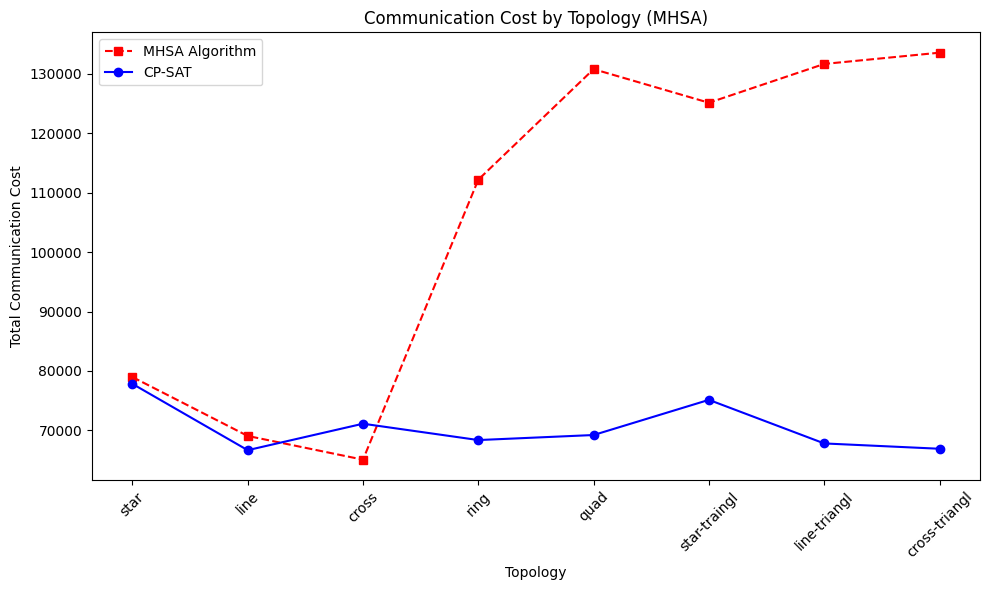

In [ ]:
"""
MHSA Topology Qubit Allocation Solver with Cost Plot

This program runs the MHSA algorithm for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install networkx matplotlib
"""

import random
import math
import matplotlib.pyplot as plt
import networkx as nx
import re
from collections import Counter

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 15  # Fixed for all topologies.

# Global cost mapping
costs_from_distance = [0, 12, 22, 32, 42]


# Define topology configurations
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}

def extract_cnot_operations(qasm_file):
    """Extracts CNOT pairs and counts from a given QASM file."""
    with open(qasm_file, 'r') as file:
        qasm_content = file.read()

    cnot_pattern = r'cx q\[(\d+)\],q\[(\d+)\]'
    cnot_pairs = re.findall(cnot_pattern, qasm_content)

    # Normalize pairs
    normalized_pairs = [tuple(sorted((int(a), int(b)))) for a, b in cnot_pairs]

    # Count occurrences
    return (Counter(normalized_pairs))

def calculate_overhead(mapping, dist_matrix):
    overhead = 0
    # print(coupled_pairs)
    for (q1, q2), count in coupled_pairs.items():
        v1 = mapping[q1]
        v2 = mapping[q2]
        d = dist_matrix[v1][v2]
        overhead += count * costs_from_distance[d]
    return overhead

def random_initial_mapping(capacities):
    allocation = {}
    available = {v: capacities[v] for v in range(NUM_NODES)}
    qubits = list(range(NUM_QUBITS))
    random.shuffle(qubits)
    for q in qubits:
        valid_nodes = [n for n in available if available[n] > 0]
        node = random.choice(valid_nodes)
        allocation[q] = node
        available[node] -= 1
    return allocation

def local_search(mapping, capacities, dist_matrix):
    current = mapping.copy()
    best_cost = calculate_overhead(current, dist_matrix)
    improved = True

    while improved:
        improved = False
        for q in range(NUM_QUBITS):
            for node in range(NUM_NODES):
                if current[q] == node:
                    continue
                count_in_node = sum(1 for v in current.values() if v == node)
                if count_in_node >= capacities[node]:
                    continue
                candidate = current.copy()
                candidate[q] = node
                candidate_cost = calculate_overhead(candidate, dist_matrix)
                if candidate_cost < best_cost:
                    current = candidate
                    best_cost = candidate_cost
                    improved = True
    return current, best_cost

def run_mhsa_for_topology(topo_config, alpha=0.9, nstage=50, neqlb=5, nstuck=5,time_limit=30):
    capacities = topo_config["capacities"]
    dist_matrix = topo_config["distance_matrix"]
    start_time = time.time()
    best_mapping = None
    best_cost = float("inf")
    current_mapping = random_initial_mapping(capacities)
    current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)


    for stage in range(nstage):
        temp = 10000
        stuck = 0
        while stuck < nstuck:
            if time.time() - start_time >= time_limit:
                return best_mapping, best_cost  # Terminate if time limit is reached

            for _ in range(neqlb):
                if time.time() - start_time >= time_limit:
                    return best_mapping, best_cost  # Terminate if time limit is reached

                q = random.randint(0, NUM_QUBITS - 1)
                valid_nodes = [n for n in range(NUM_NODES) if sum(1 for v in current_mapping.values() if v == n) < capacities[n] or current_mapping[q] == n]
                if not valid_nodes:
                    continue
                node = random.choice(valid_nodes)
                neighbor = current_mapping.copy()
                neighbor[q] = node

                delta = calculate_overhead(neighbor, dist_matrix) - calculate_overhead(current_mapping, dist_matrix)
                if delta < 0 or random.random() < math.exp(-delta / temp):
                    current_mapping = neighbor
                    current_cost = calculate_overhead(current_mapping, dist_matrix)
                    if current_cost < best_cost:
                        best_mapping = current_mapping.copy()
                        best_cost = current_cost
                    stuck = 0
                else:
                    stuck += 1
            temp *= alpha
        current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)
        if current_cost < best_cost:
            best_mapping = current_mapping.copy()
            best_cost = current_cost
    return best_mapping, best_cost

def main(qasm_file):
    topology_names = []
    mhsa_costs = []
    costs=[77832,66664,71120,68368,69216,75136,67800,66904]

    global coupled_pairs
    coupled_pairs = extract_cnot_operations(qasm_file)
    # print(coupled_pairs.items())
    print("\n=================================================")
    print("Solving topologies using MHSA algorithm...")

    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        cost=0
        for i in range(10):
          solution, cost_val = run_mhsa_for_topology(topo)
          cost+=cost_val
        # solution2, cost_val2 = solve_topology(topo)
        cost/=10
        print(f"Total Communication Cost (MHSA): {cost}")
        # print(f"Total Communication Cost (CP-SAT): {cost_val2}")
        topology_names.append(name)
        mhsa_costs.append(cost)
        # costs.append(cost_val2)


    # Plot result
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, mhsa_costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.plot(x, costs, marker='o', linestyle='-', color='b',label='CP-SAT')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()





if __name__ == '__main__':
    qasm_file ="/content/co14_215.qasm"
    main(qasm_file)



misex1


Solving topologies using MHSA algorithm...

Topology: star
Total Communication Cost (MHSA): 20496.0

Topology: line
Total Communication Cost (MHSA): 19344.0

Topology: cross
Total Communication Cost (MHSA): 18694.8

Topology: ring
Total Communication Cost (MHSA): 30248.4

Topology: quad
Total Communication Cost (MHSA): 34053.2

Topology: star-traingl
Total Communication Cost (MHSA): 34112.4

Topology: line-triangl
Total Communication Cost (MHSA): 35943.2

Topology: cross-triangl
Total Communication Cost (MHSA): 35385.2


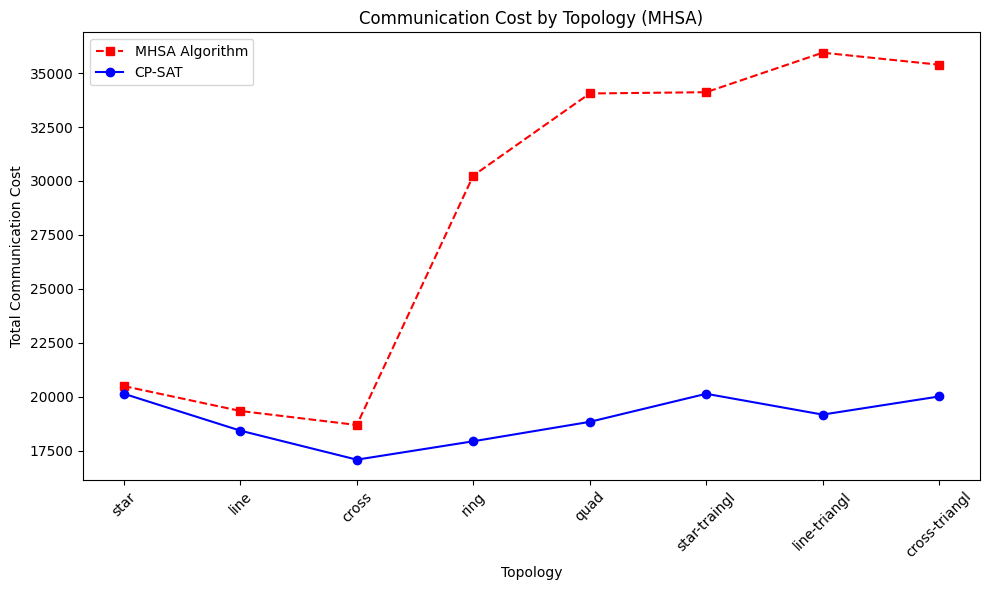

In [ ]:
"""
MHSA Topology Qubit Allocation Solver with Cost Plot

This program runs the MHSA algorithm for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install networkx matplotlib
"""

import random
import math
import matplotlib.pyplot as plt
import networkx as nx
import re
from collections import Counter

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 15  # Fixed for all topologies.

# Global cost mapping
costs_from_distance = [0, 12, 22, 32, 42]


# Define topology configurations
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}

def extract_cnot_operations(qasm_file):
    """Extracts CNOT pairs and counts from a given QASM file."""
    with open(qasm_file, 'r') as file:
        qasm_content = file.read()

    cnot_pattern = r'cx q\[(\d+)\],q\[(\d+)\]'
    cnot_pairs = re.findall(cnot_pattern, qasm_content)

    # Normalize pairs
    normalized_pairs = [tuple(sorted((int(a), int(b)))) for a, b in cnot_pairs]

    # Count occurrences
    return (Counter(normalized_pairs))

def calculate_overhead(mapping, dist_matrix):
    overhead = 0
    # print(coupled_pairs)
    for (q1, q2), count in coupled_pairs.items():
        v1 = mapping[q1]
        v2 = mapping[q2]
        d = dist_matrix[v1][v2]
        overhead += count * costs_from_distance[d]
    return overhead

def random_initial_mapping(capacities):
    allocation = {}
    available = {v: capacities[v] for v in range(NUM_NODES)}
    qubits = list(range(NUM_QUBITS))
    random.shuffle(qubits)
    for q in qubits:
        valid_nodes = [n for n in available if available[n] > 0]
        node = random.choice(valid_nodes)
        allocation[q] = node
        available[node] -= 1
    return allocation

def local_search(mapping, capacities, dist_matrix):
    current = mapping.copy()
    best_cost = calculate_overhead(current, dist_matrix)
    improved = True

    while improved:
        improved = False
        for q in range(NUM_QUBITS):
            for node in range(NUM_NODES):
                if current[q] == node:
                    continue
                count_in_node = sum(1 for v in current.values() if v == node)
                if count_in_node >= capacities[node]:
                    continue
                candidate = current.copy()
                candidate[q] = node
                candidate_cost = calculate_overhead(candidate, dist_matrix)
                if candidate_cost < best_cost:
                    current = candidate
                    best_cost = candidate_cost
                    improved = True
    return current, best_cost

def run_mhsa_for_topology(topo_config, alpha=0.9, nstage=50, neqlb=5, nstuck=5,time_limit=30):
    capacities = topo_config["capacities"]
    dist_matrix = topo_config["distance_matrix"]
    start_time = time.time()
    best_mapping = None
    best_cost = float("inf")
    current_mapping = random_initial_mapping(capacities)
    current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)


    for stage in range(nstage):
        temp = 4000
        stuck = 0
        while stuck < nstuck:
            if time.time() - start_time >= time_limit:
                return best_mapping, best_cost  # Terminate if time limit is reached

            for _ in range(neqlb):
                if time.time() - start_time >= time_limit:
                    return best_mapping, best_cost  # Terminate if time limit is reached

                q = random.randint(0, NUM_QUBITS - 1)
                valid_nodes = [n for n in range(NUM_NODES) if sum(1 for v in current_mapping.values() if v == n) < capacities[n] or current_mapping[q] == n]
                if not valid_nodes:
                    continue
                node = random.choice(valid_nodes)
                neighbor = current_mapping.copy()
                neighbor[q] = node

                delta = calculate_overhead(neighbor, dist_matrix) - calculate_overhead(current_mapping, dist_matrix)
                if delta < 0 or random.random() < math.exp(-delta / temp):
                    current_mapping = neighbor
                    current_cost = calculate_overhead(current_mapping, dist_matrix)
                    if current_cost < best_cost:
                        best_mapping = current_mapping.copy()
                        best_cost = current_cost
                    stuck = 0
                else:
                    stuck += 1
            temp *= alpha
        current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)
        if current_cost < best_cost:
            best_mapping = current_mapping.copy()
            best_cost = current_cost
    return best_mapping, best_cost

def main(qasm_file):
    topology_names = []
    mhsa_costs = []
    costs=[20140,18432,17088,17940,18840,20140,19176,20016]

    global coupled_pairs
    coupled_pairs = extract_cnot_operations(qasm_file)
    # print(coupled_pairs.items())
    print("\n=================================================")
    print("Solving topologies using MHSA algorithm...")

    for name, topo in topologies.items():
        print(f"\nTopology: {name}")

        cost=0
        for i in range(10):
          solution, cost_val = run_mhsa_for_topology(topo)
          cost+=cost_val
        # solution2, cost_val2 = solve_topology(topo)
        cost/=10
        print(f"Total Communication Cost (MHSA): {cost}")
        # print(f"Total Communication Cost (CP-SAT): {cost_val2}")
        topology_names.append(name)
        mhsa_costs.append(cost)
        # costs.append(cost_val2)


    # Plot result
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, mhsa_costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.plot(x, costs, marker='o', linestyle='-', color='b',label='CP-SAT')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()





if __name__ == '__main__':
    qasm_file ="/content/misex1_241.qasm"
    main(qasm_file)



In [ ]:
"""
MHSA Topology Qubit Allocation Solver with Cost Plot

This program runs the MHSA algorithm for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install networkx matplotlib
"""

import random
import math
import matplotlib.pyplot as plt
import networkx as nx
import re
from collections import Counter

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 15  # Fixed for all topologies.

# Global cost mapping
costs_from_distance = [0, 12, 22, 32, 42]


# Define topology configurations
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}

def extract_cnot_operations(qasm_file):
    """Extracts CNOT pairs and counts from a given QASM file."""
    with open(qasm_file, 'r') as file:
        qasm_content = file.read()

    cnot_pattern = r'cx q\[(\d+)\],q\[(\d+)\]'
    cnot_pairs = re.findall(cnot_pattern, qasm_content)

    # Normalize pairs
    normalized_pairs = [tuple(sorted((int(a), int(b)))) for a, b in cnot_pairs]

    # Count occurrences
    return (Counter(normalized_pairs))

def calculate_overhead(mapping, dist_matrix):
    overhead = 0
    # print(coupled_pairs)
    for (q1, q2), count in coupled_pairs.items():
        v1 = mapping[q1]
        v2 = mapping[q2]
        d = dist_matrix[v1][v2]
        overhead += count * costs_from_distance[d]
    return overhead

def random_initial_mapping(capacities):
    allocation = {}
    available = {v: capacities[v] for v in range(NUM_NODES)}
    qubits = list(range(NUM_QUBITS))
    random.shuffle(qubits)
    for q in qubits:
        valid_nodes = [n for n in available if available[n] > 0]
        node = random.choice(valid_nodes)
        allocation[q] = node
        available[node] -= 1
    return allocation

def local_search(mapping, capacities, dist_matrix):
    current = mapping.copy()
    best_cost = calculate_overhead(current, dist_matrix)
    improved = True

    while improved:
        improved = False
        for q in range(NUM_QUBITS):
            for node in range(NUM_NODES):
                if current[q] == node:
                    continue
                count_in_node = sum(1 for v in current.values() if v == node)
                if count_in_node >= capacities[node]:
                    continue
                candidate = current.copy()
                candidate[q] = node
                candidate_cost = calculate_overhead(candidate, dist_matrix)
                if candidate_cost < best_cost:
                    current = candidate
                    best_cost = candidate_cost
                    improved = True
    return current, best_cost

def run_mhsa_for_topology(topo_config, alpha=0.9, nstage=50, neqlb=5, nstuck=5,time_limit=30):
    capacities = topo_config["capacities"]
    dist_matrix = topo_config["distance_matrix"]
    start_time = time.time()
    best_mapping = None
    best_cost = float("inf")
    current_mapping = random_initial_mapping(capacities)
    current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)


    for stage in range(nstage):
        temp = 4000
        stuck = 0
        while stuck < nstuck:
            # if time.time() - start_time >= time_limit:
            #     return best_mapping, best_cost  # Terminate if time limit is reached

            for _ in range(neqlb):
                # if time.time() - start_time >= time_limit:
                #     return best_mapping, best_cost  # Terminate if time limit is reached

                q = random.randint(0, NUM_QUBITS - 1)
                valid_nodes = [n for n in range(NUM_NODES) if sum(1 for v in current_mapping.values() if v == n) < capacities[n] or current_mapping[q] == n]
                if not valid_nodes:
                    continue
                node = random.choice(valid_nodes)
                neighbor = current_mapping.copy()
                neighbor[q] = node

                delta = calculate_overhead(neighbor, dist_matrix) - calculate_overhead(current_mapping, dist_matrix)
                if delta < 0 or random.random() < math.exp(-delta / temp):
                    current_mapping = neighbor
                    current_cost = calculate_overhead(current_mapping, dist_matrix)
                    if current_cost < best_cost:
                        best_mapping = current_mapping.copy()
                        best_cost = current_cost
                    stuck = 0
                else:
                    stuck += 1
            temp *= alpha
        current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)

        if current_cost < best_cost:
            best_mapping = current_mapping.copy()
            best_cost = current_cost
        print(f"Stage {stage + 1}: Best Cost = {best_cost}")
    return best_mapping, best_cost

def main(qasm_file):
    topology_names = []
    mhsa_costs = []
    costs=[20140,18432,17088,17940,18840,20140,19176,20016]

    global coupled_pairs
    coupled_pairs = extract_cnot_operations(qasm_file)
    # print(coupled_pairs.items())
    print("\n=================================================")
    print("Solving topologies using MHSA algorithm...")

    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        if name!="ring":
          continue
        cost=0
        for i in range(1):
          solution, cost_val = run_mhsa_for_topology(topo)
          cost+=cost_val
        # solution2, cost_val2 = solve_topology(topo)
        cost/=1
        print(f"Total Communication Cost (MHSA): {cost}")
        # print(f"Total Communication Cost (CP-SAT): {cost_val2}")
        topology_names.append(name)
        mhsa_costs.append(cost)
        # costs.append(cost_val2)


    # Plot result
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, mhsa_costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.plot(x, costs, marker='o', linestyle='-', color='b',label='CP-SAT')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()





if __name__ == '__main__':
    qasm_file ="/content/misex1_241.qasm"
    main(qasm_file)




Solving topologies using MHSA algorithm...

Topology: star

Topology: line

Topology: cross

Topology: ring
